# RSNA 2024 Data preprocessing

## Packages and WD

In [1]:
import os
# Set the working directory
os.chdir("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
print(os.getcwd())


/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification


In [2]:
# Installed packages 
#!pip install opendatasets
#!pip install --upgrade seaborn
#!pip install pydicom
#!pip install torchio
#!pip install scikit-image

In [3]:
# Used packages 
import opendatasets as od
import pandas as pd
import shutil, json, zipfile, random, math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pydicom
from pathlib import Path
from IPython.display import clear_output
from sklearn.model_selection import train_test_split

import cv2
from PIL import Image
import torchvision.transforms as transforms

import plotly.offline as pyo
from scipy.interpolate import griddata
import plotly.offline as pyo
from scipy.interpolate import griddata
import plotly.graph_objects as go

## Data import

In [4]:
path = "./BC-data/data-rsna2024"
train_data = pd.read_csv("./BC-data/data-rsna2024/train.csv")
train_label = pd.read_csv("./BC-data/data-rsna2024/train_label_coordinates.csv")
train_des = pd.read_csv("./BC-data/data-rsna2024/train_series_descriptions.csv")

**train.csv** = Labels for the train set.
* study_id - The study ID. Each study may include multiple series of images.
* [condition]\_[level] - The target labels, such as spinal_canal_stenosis_l1_l2, with the severity levels of Normal/Mild, Moderate, or Severe. Some entries have incomplete labels.

In [5]:
train_data.head(5)

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild


**train_label_coordinates.csv**
* study_id
* series_id - The imagery series ID.
* instance_number - The image's order number within the 3D stack.
* condition - There are three core conditions: spinal canal stenosis, neural_foraminal_narrowing, and subarticular_stenosis. The latter two are considered for each side of the spine.
* level - The relevant vertebrae, such as l3_l4
* [x/y] - The x/y coordinates for the center of the area that defined the label.

In [6]:
train_label.head(5)

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


**[train/test]_series_descriptions.csv**
* study_id
* series_id
* series_description The scan's orientation.

In [7]:
train_des.head(5)

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


## Data preprocessing
To create a unified dataset, we need to merge these tables based on their relationships:

1. **Merge train_label with train_des:**
We use study_id and series_id as keys to bring in the series_description for each record in train_label.

2. **Merge train_label with train_data:**
For each row in train_label, we generate the appropriate severity column name by combining condition and level (lowercased, spaces replaced with underscores).
We use study_id to merge and fetch the corresponding severity from train_data.

In [8]:
data_merged = pd.merge(train_label, train_des, on=['study_id', 'series_id'], how='left')

# Function to determine the column name in train_data
def gen_sev_col(row):
    condition_col = f"{row['condition'].lower().replace(' ', '_')}_{row['level'].lower().replace('/', '_')}"
    return condition_col

# Create a severity_col in data_merged applying gen_sev_col
data_merged['severity_col'] = data_merged.apply(gen_sev_col, axis=1)

# Merge with train_data on study_id
data_merged = pd.merge(data_merged, train_data, on='study_id', how='left')

# Extract only severity values matching with severity_col
data_merged['severity'] = data_merged.apply(lambda row: row[row['severity_col']], axis=1)

# Create unique key id
data_merged['row_id'] = (data_merged['study_id'].astype(str) + '_' + data_merged['severity_col'].astype(str))

# Filter columns
data_merged = data_merged[['row_id','study_id', 'series_id', 'condition', 'level', 'series_description', 'instance_number', 'x', 'y', 'severity']]


In [9]:
# Create the img_path column
train_dir = "./BC-data/data-rsna2024/train_images"

data_merged['img_path'] = (
    f'{train_dir}' + '/' +
    data_merged['study_id'].astype(str) + '/' +
    data_merged['series_id'].astype(str) + '/' +
    data_merged['instance_number'].astype(str) + '.dcm'
)

data_merged.head()

,row_id,study_id,series_id,condition,level,series_description,instance_number,x,y,severity,img_path
0,4003253_spinal_canal_stenosis_l1_l2,4003253,702807833,Spinal Canal Stenosis,L1/L2,Sagittal T2/STIR,8,322.831858,227.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
1,4003253_spinal_canal_stenosis_l2_l3,4003253,702807833,Spinal Canal Stenosis,L2/L3,Sagittal T2/STIR,8,320.571429,295.714286,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
2,4003253_spinal_canal_stenosis_l3_l4,4003253,702807833,Spinal Canal Stenosis,L3/L4,Sagittal T2/STIR,8,323.030303,371.818182,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
3,4003253_spinal_canal_stenosis_l4_l5,4003253,702807833,Spinal Canal Stenosis,L4/L5,Sagittal T2/STIR,8,335.292035,427.327434,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...
4,4003253_spinal_canal_stenosis_l5_s1,4003253,702807833,Spinal Canal Stenosis,L5/S1,Sagittal T2/STIR,8,353.415929,483.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...


# EDA 

In [10]:
# Number o cases 
print("Number of cases: ", len(data_merged["study_id"].unique()))
# Number of MRI sequences 
print("Number of MRI sequences: ", len(data_merged["series_id"].unique()))
# Number of total observations
print("Number of observations: ", len(data_merged["study_id"]))

Number of cases:  1974
Number of MRI sequences:  6291
Number of observations:  48692


In [11]:
data_merged.groupby(["condition", "series_description"]).size().unstack(fill_value=0)

series_description,Axial T2,Sagittal T1,Sagittal T2/STIR
condition,,,
Left Neural Foraminal Narrowing,0,9860,0
Left Subarticular Stenosis,9608,0,0
Right Neural Foraminal Narrowing,0,9859,0
Right Subarticular Stenosis,9612,0,0
Spinal Canal Stenosis,0,5,9748


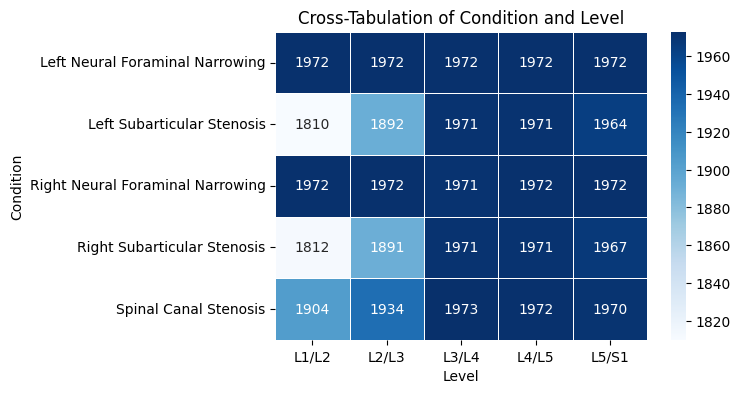

In [12]:
# Distribution of observations according to level x condition
crosstab_data = pd.crosstab(train_label['condition'], train_label['level'])
plt.figure(figsize=(6, 4))
sns.heatmap(crosstab_data, annot=True, fmt='d', linewidths=0.5, cmap=plt.cm.Blues)
plt.title('Cross-Tabulation of Condition and Level')
plt.xlabel('Level')
plt.ylabel('Condition')
plt.show()

In [13]:
# Cell 1: count slices + compute averages
slice_repetition_df = (
    data_merged
    .dropna(subset=["study_id", "condition", "level", "img_path"])
    .groupby(["study_id", "condition", "level"])["img_path"]
    .nunique()
    .reset_index(name="n_slices")
)

level_order = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

slice_repetition_df["level"] = pd.Categorical(
    slice_repetition_df["level"],
    categories=level_order,
    ordered=True
)

# --- NEW PART: average number of slices ---
avg_slices_df = (
    slice_repetition_df
    .groupby(["condition", "level"], observed=True)["n_slices"]
    .mean()
    .reset_index(name="avg_slices")
)

avg_slices_df = avg_slices_df.sort_values(["condition", "level"])

#avg_slices_df
#one slice per conditionxlevel

In [14]:
# Cell 1: count how many classifications use the same slice

same_slice_df = (
    data_merged
    .dropna(subset=["img_path", "condition", "level"])
    .groupby("img_path")
    .agg(
        n_classifications=("condition", "size"),
        n_conditions=("condition", "nunique"),
        n_levels=("level", "nunique"),
        conditions=("condition", lambda x: sorted(x.unique())),
        levels=("level", lambda x: sorted(x.unique())),
        study_id=("study_id", "first"),
        series_description=("series_description", "first"),
    )
    .reset_index()
)

same_slice_df.sort_values("n_classifications", ascending=False).head(5)

,img_path,n_classifications,n_conditions,n_levels,conditions,levels,study_id,series_description
2429,./BC-data/data-rsna2024/train_images/139577391...,10,2,5,"[Left Neural Foraminal Narrowing, Right Neural...","[L1/L2, L2/L3, L3/L4, L4/L5, L5/S1]",1395773918,Sagittal T1
9450,./BC-data/data-rsna2024/train_images/253067935...,9,2,5,"[Left Neural Foraminal Narrowing, Right Neural...","[L1/L2, L2/L3, L3/L4, L4/L5, L5/S1]",2530679352,Sagittal T1
10423,./BC-data/data-rsna2024/train_images/266298953...,8,2,4,"[Left Neural Foraminal Narrowing, Right Neural...","[L2/L3, L3/L4, L4/L5, L5/S1]",2662989538,Sagittal T1
13585,./BC-data/data-rsna2024/train_images/315626963...,7,2,4,"[Left Neural Foraminal Narrowing, Right Neural...","[L1/L2, L2/L3, L4/L5, L5/S1]",3156269631,Sagittal T1
8596,./BC-data/data-rsna2024/train_images/238857766...,6,2,3,"[Left Neural Foraminal Narrowing, Right Neural...","[L3/L4, L4/L5, L5/S1]",2388577668,Sagittal T1


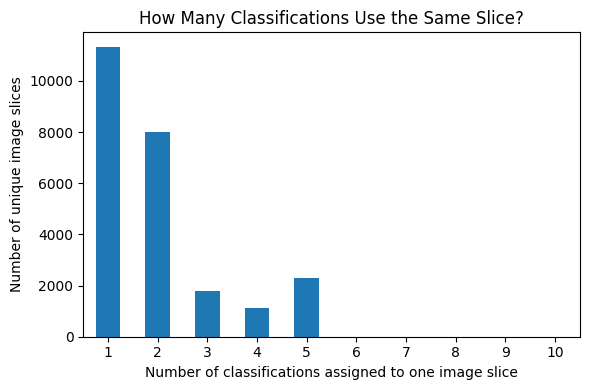

In [15]:
# Cell 2: summary + distribution plot
summary = (
    same_slice_df["n_classifications"]
    .value_counts()
    .sort_index()
    .reset_index()
)

summary.columns = ["n_classifications_on_same_slice", "n_slices"]

ax = summary.plot(
    x="n_classifications_on_same_slice",
    y="n_slices",
    kind="bar",
    legend=False,
    figsize=(6, 4)
)

plt.title("How Many Classifications Use the Same Slice?")
plt.xlabel("Number of classifications assigned to one image slice")
plt.ylabel("Number of unique image slices")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Visualization

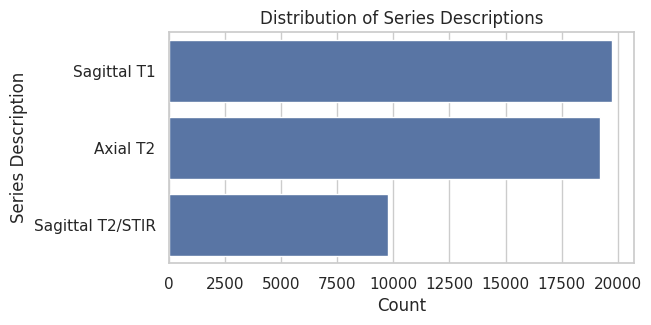

In [16]:
#  Distribution of series description 
sns.set(style="whitegrid")
plt.figure(figsize=(6, 3))
sns.countplot(y='series_description', data=data_merged, order=data_merged['series_description'].value_counts().index)
plt.title('Distribution of Series Descriptions')
plt.xlabel('Count')
plt.ylabel('Series Description')
plt.show()

#### Distribution of conditions by description 


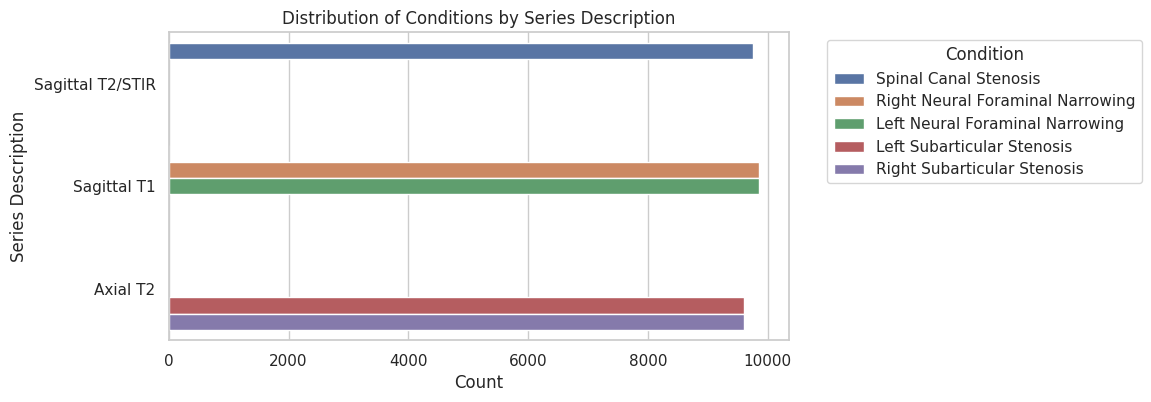

In [17]:
# For which condition is used each MRI plane/type
plt.figure(figsize=(8, 4))
sns.countplot(y='series_description', hue='condition', data=data_merged)
plt.title('Distribution of Conditions by Series Description')
plt.xlabel('Count')
plt.ylabel('Series Description')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

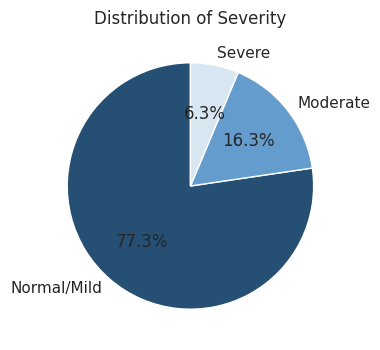

In [18]:
# Distribution of target variable
severity_counts = data_merged['severity'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=90, colors=['#254f73', '#649dcd', '#d8e6f2'])
plt.title('Distribution of Severity')
plt.show()

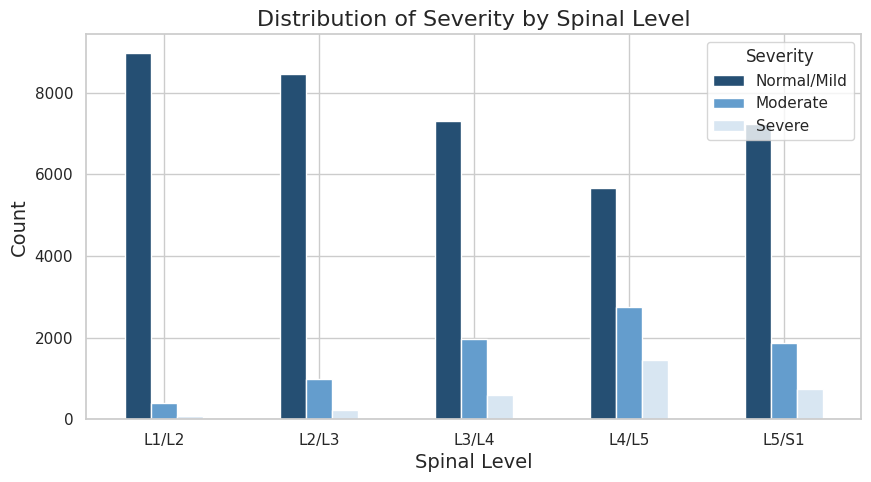

In [19]:
# Distribution of severity by spinal level 
data_merged['severity'] = pd.Categorical(data_merged['severity'], categories=['Normal/Mild', 'Moderate', 'Severe'], ordered=True)
sev_dist = pd.crosstab(data_merged['level'], data_merged['severity'])
sev_dist.plot(kind='bar', stacked=False, figsize=(10, 5), color=['#254f73', '#649dcd', '#d8e6f2'])
plt.title('Distribution of Severity by Spinal Level', fontsize=16)
plt.xlabel('Spinal Level', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Severity')
plt.show()

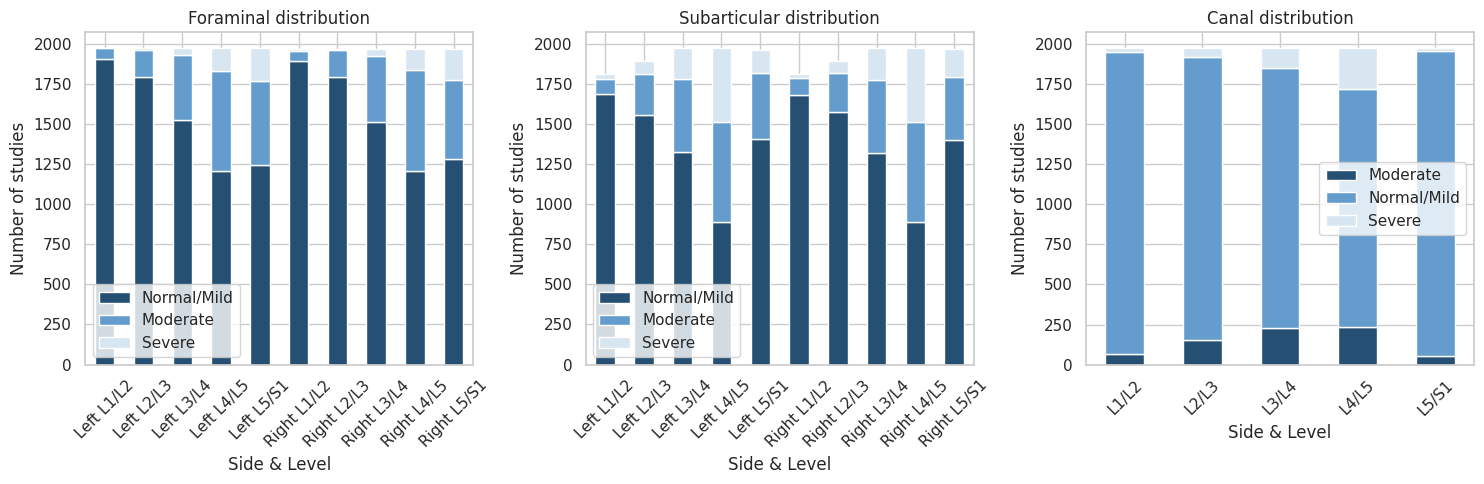

In [21]:
import re
import warnings
import pandas as pd
import matplotlib.pyplot as plt

# Subplots for severity by spinal level for each condition
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, d in enumerate(["foraminal", "subarticular", "canal"]):
    diagnosis = list(filter(lambda x: x.find(d) > -1, train_data.columns))
    dff = train_data[diagnosis]

    with warnings.catch_warnings():
        warnings.simplefilter(action="ignore", category=FutureWarning)
        value_counts = dff.apply(pd.value_counts).fillna(0).T

    # Clean labels: keep only side and level
    clean_labels = []

    for label in value_counts.index:
        label_clean = label.lower()

        if "left" in label_clean:
            side = "Left"
        elif "right" in label_clean:
            side = "Right"
        else:
            side = ""

        level_match = re.search(r"l[1-5]_l[2-5]|l5_s1", label_clean)

        if level_match:
            level = level_match.group().upper().replace("_", "/")
        else:
            level = label

        if side:
            clean_labels.append(f"{side} {level}")
        else:
            clean_labels.append(level)

    value_counts.index = clean_labels

    value_counts.plot(
        kind="bar",
        stacked=True,
        ax=axes[idx],
        color=["#254f73", "#649dcd", "#d8e6f2"]
    )

    axes[idx].set_title(f"{d.capitalize()} distribution")
    axes[idx].set_xlabel("Side & Level")
    axes[idx].set_ylabel("Number of studies")
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Coordinates distribution

In [21]:
# Final adjustment: coordinate normalization and outlier inspection
from tqdm.auto import tqdm

LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

# Reuse the dataset path defined earlier in the notebook.
DATA_ROOT = Path(path)
df_loc = train_label.copy()


def rsna_dicom_path(row, data_root=DATA_ROOT):
    """Return the DICOM path for one coordinate row."""
    return (
        Path(data_root)
        / "train_images"
        / str(row["study_id"])
        / str(row["series_id"])
        / f"{int(row['instance_number'])}.dcm"
    )


def add_image_size_and_normalized_coords(df, data_root=DATA_ROOT):
    """Add image dimensions plus x/y coordinates normalized to [0, 1]."""
    df = df.copy()

    height_by_key = {}
    width_by_key = {}
    heights = []
    widths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Reading DICOM sizes"):
        key = (row["study_id"], row["series_id"], int(row["instance_number"]))

        if key not in height_by_key:
            dicom_file = rsna_dicom_path(row, data_root)
            ds = pydicom.dcmread(str(dicom_file), stop_before_pixels=True)
            height_by_key[key] = int(ds.Rows)
            width_by_key[key] = int(ds.Columns)

        heights.append(height_by_key[key])
        widths.append(width_by_key[key])

    df["image_height"] = heights
    df["image_width"] = widths
    df["x_norm"] = df["x"] / df["image_width"]
    df["y_norm"] = df["y"] / df["image_height"]

    return df


def plot_normalized_coordinate_distribution(df):
    """Plot normalized coordinate distribution by lumbar level."""
    plt.figure(figsize=(6, 6))

    for level in LEVELS:
        d = df[df["level"] == level]
        if len(d) == 0:
            continue
        plt.scatter(d["x_norm"], d["y_norm"], s=12, alpha=0.4, label=level)

    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    plt.ylim(1, 0)
    plt.xlabel("x / image_width")
    plt.ylabel("y / image_height")
    plt.title("Normalized coordinate distribution by lumbar level")
    plt.legend(title="Level")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def load_dicom_image(dicom_file):
    """Load and min-max normalize a DICOM image for visualization."""
    ds = pydicom.dcmread(str(dicom_file))
    img = ds.pixel_array.astype(np.float32)
    img -= img.min()
    img /= img.max() + 1e-8
    return img


def plot_rows_with_points(df, data_root=DATA_ROOT, n=24, ncols=4, figsize_per_img=4):
    """Display selected DICOM slices with the labelled coordinate overlaid."""
    df = df.reset_index(drop=True).copy()
    n = min(n, len(df))

    if n == 0:
        print("No rows to plot.")
        return

    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * figsize_per_img, nrows * figsize_per_img),
    )
    axes = np.array(axes).reshape(-1)

    for ax in axes[n:]:
        ax.axis("off")

    for i in range(n):
        row = df.iloc[i]
        dicom_file = rsna_dicom_path(row, data_root)
        img = load_dicom_image(dicom_file)

        ax = axes[i]
        ax.imshow(img, cmap="gray")
        ax.scatter(row["x"], row["y"], c="red", s=70, marker="x", linewidths=2)
        ax.set_title(
            f"{row['level']} | x_norm={row['x_norm']:.2f}, y_norm={row['y_norm']:.2f}\n"
            f"study={row['study_id']} | series={row['series_id']}\n"
            f"inst={int(row['instance_number'])} | shape={int(row['image_height'])}x{int(row['image_width'])}",
            fontsize=9,
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Build plotting dataframe and inspect coordinates located unusually far left.
df_coords = add_image_size_and_normalized_coords(df_loc, DATA_ROOT)
display(df_coords.head())


Reading DICOM sizes:   0%|          | 0/48692 [00:00<?, ?it/s]

,study_id,series_id,instance_number,condition,level,x,y,image_height,image_width,x_norm,y_norm
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602,640,640,0.504425,0.356195
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286,640,640,0.500893,0.462054
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182,640,640,0.504735,0.580966
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434,640,640,0.523894,0.667699
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602,640,640,0.552212,0.756195


Number of images with x_norm < 0.2: 15


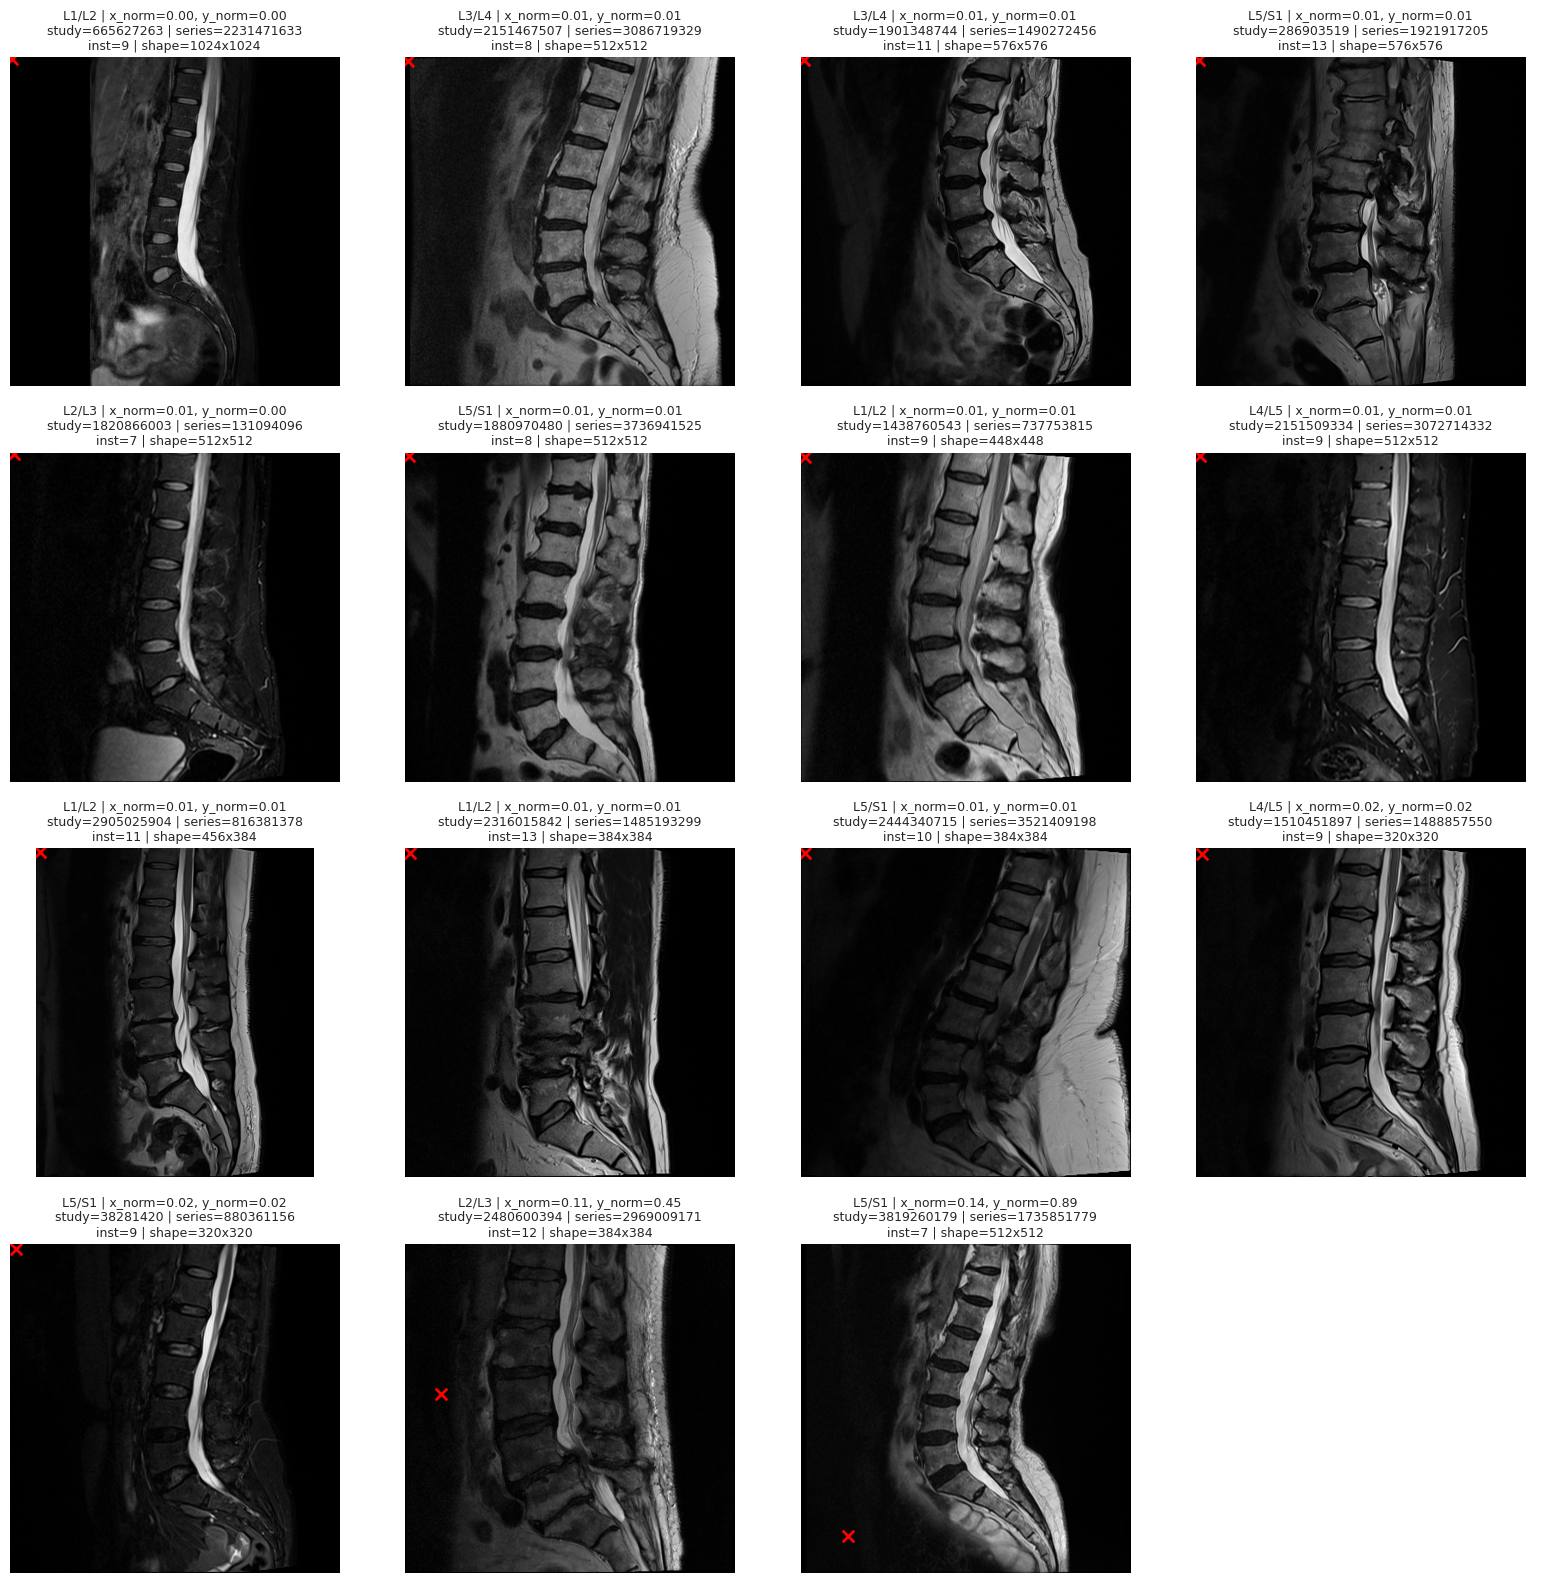

In [22]:
x_left = df_coords[df_coords["x_norm"] < 0.2].copy()
x_left = x_left.sort_values(["x_norm", "level", "study_id", "series_id", "instance_number"])

print("Number of images with x_norm < 0.2:", len(x_left))

N = len(x_left)
plot_rows_with_points(x_left, DATA_ROOT, n=N, ncols=4)

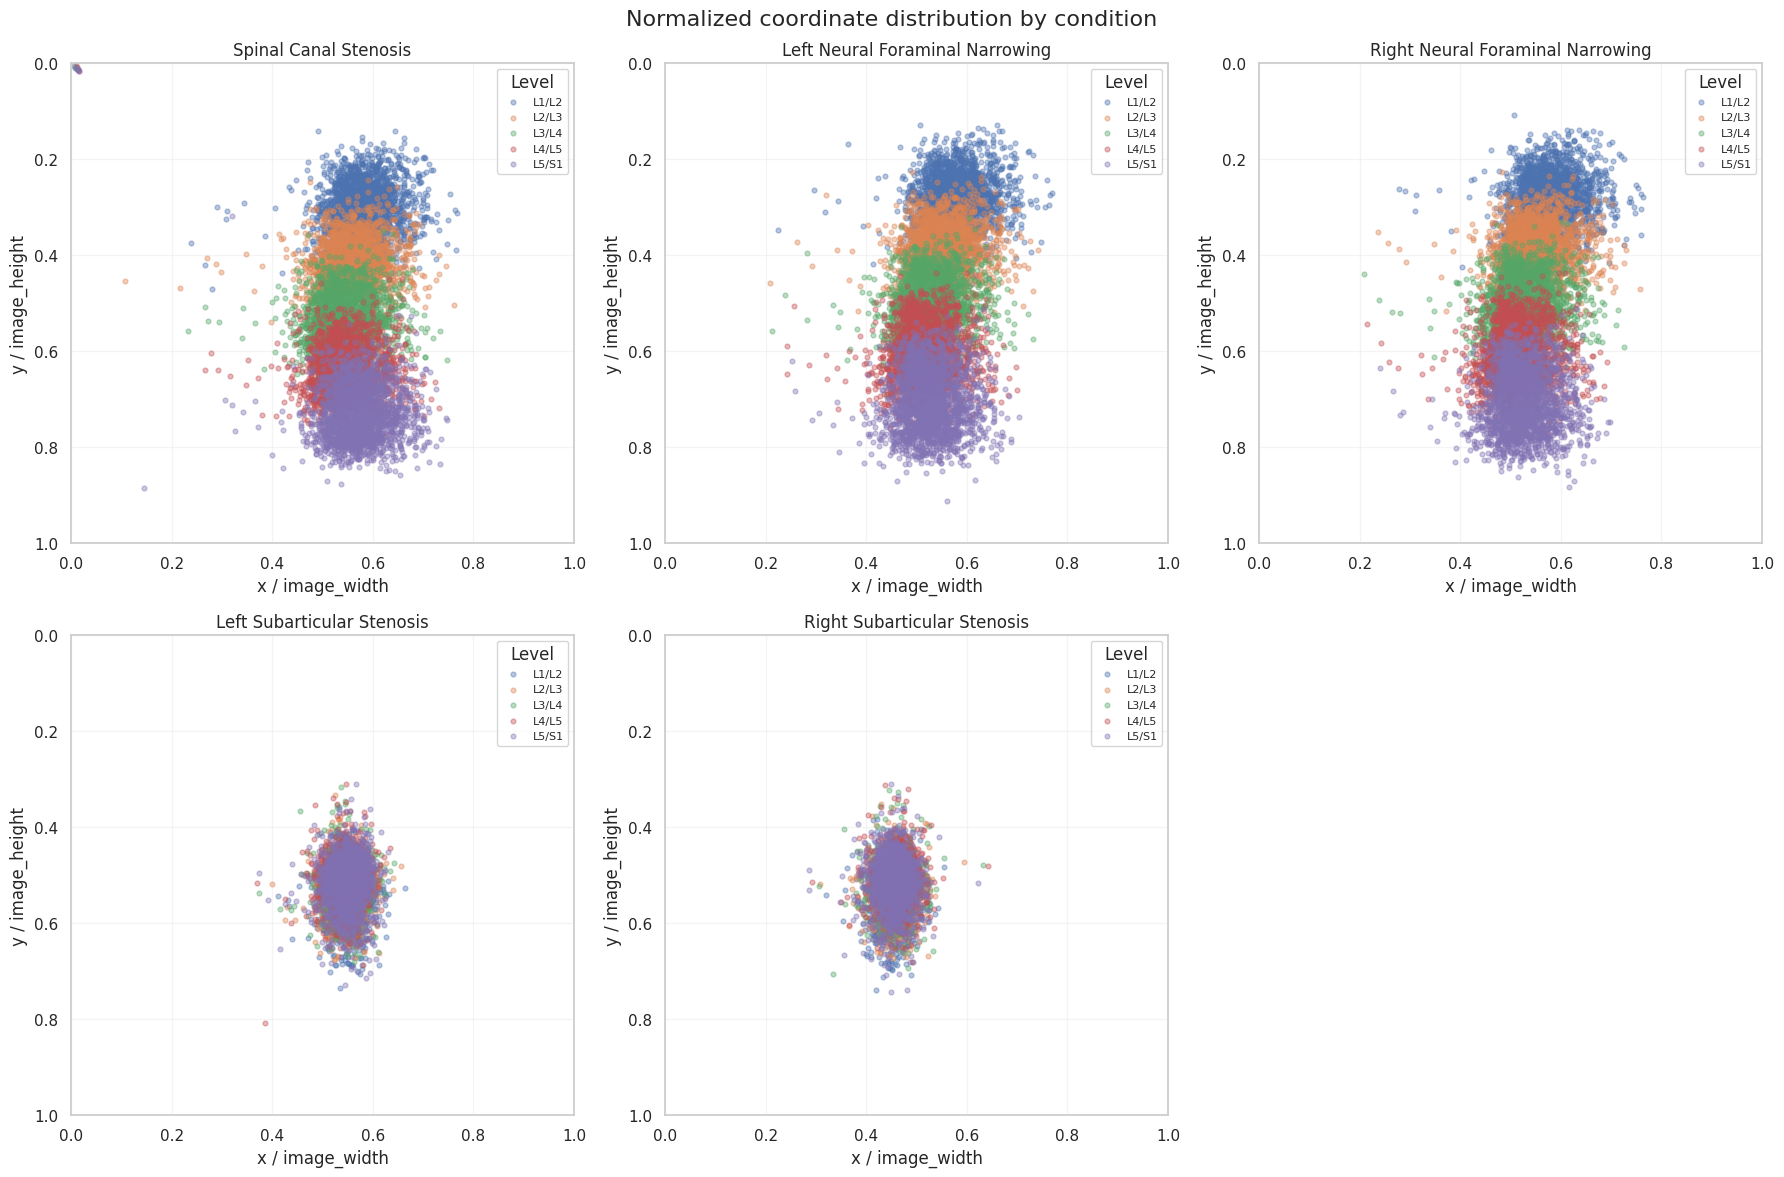

In [23]:
# Coordinate distribution scatter plots for each condition in a grid

import math
import numpy as np
import matplotlib.pyplot as plt

CONDITIONS = [
    "Spinal Canal Stenosis",
    "Left Neural Foraminal Narrowing",
    "Right Neural Foraminal Narrowing",
    "Left Subarticular Stenosis",
    "Right Subarticular Stenosis",
]

# Keep only conditions that actually exist in df_coords
CONDITIONS = [c for c in CONDITIONS if c in df_coords["condition"].unique()]

n_conditions = len(CONDITIONS)
ncols = 3
nrows = math.ceil(n_conditions / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
axes = np.array(axes).reshape(-1)

for ax, condition in zip(axes, CONDITIONS):
    d_cond = df_coords[df_coords["condition"] == condition]

    for level in LEVELS:
        d = d_cond[d_cond["level"] == level]

        if len(d) == 0:
            continue

        ax.scatter(
            d["x_norm"],
            d["y_norm"],
            s=12,
            alpha=0.4,
            label=level,
        )

    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_xlabel("x / image_width")
    ax.set_ylabel("y / image_height")
    ax.set_title(condition)
    ax.grid(True, alpha=0.2)
    ax.legend(title="Level", fontsize=8)

# Hide unused subplot
for ax in axes[n_conditions:]:
    ax.axis("off")

fig.suptitle("Normalized coordinate distribution by condition", fontsize=16)
plt.tight_layout()
plt.show()

In [25]:
# Append coordinate/image-size columns from df_coords to data_merged,
# then filter out rows with x_norm < 0.2

cols_to_add = [
    "study_id",
    "series_id",
    "instance_number",
    "condition",
    "level",
    "image_height",
    "image_width",
    "x_norm",
    "y_norm",
]

data_merged = data_merged.merge(
    df_coords[cols_to_add],
    on=["study_id", "series_id", "instance_number", "condition", "level"],
    how="left",
)

# Filter out rows where x_norm < 0.2
# Keeps rows where x_norm is missing, in case some rows did not have coordinates
data_merged = data_merged[
    data_merged["x_norm"].isna() | (data_merged["x_norm"] >= 0.2)
].copy()

data_merged.reset_index(drop=True, inplace=True)

print("Updated data_merged shape:", data_merged.shape)
print("Rows with x_norm < 0.2 remaining:", (data_merged["x_norm"] < 0.2).sum())

data_merged.head()

Updated data_merged shape: (48677, 15)
Rows with x_norm < 0.2 remaining: 0


,row_id,study_id,series_id,condition,level,series_description,instance_number,x,y,severity,img_path,image_height,image_width,x_norm,y_norm
0,4003253_spinal_canal_stenosis_l1_l2,4003253,702807833,Spinal Canal Stenosis,L1/L2,Sagittal T2/STIR,8,322.831858,227.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.504425,0.356195
1,4003253_spinal_canal_stenosis_l2_l3,4003253,702807833,Spinal Canal Stenosis,L2/L3,Sagittal T2/STIR,8,320.571429,295.714286,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.500893,0.462054
2,4003253_spinal_canal_stenosis_l3_l4,4003253,702807833,Spinal Canal Stenosis,L3/L4,Sagittal T2/STIR,8,323.030303,371.818182,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.504735,0.580966
3,4003253_spinal_canal_stenosis_l4_l5,4003253,702807833,Spinal Canal Stenosis,L4/L5,Sagittal T2/STIR,8,335.292035,427.327434,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.523894,0.667699
4,4003253_spinal_canal_stenosis_l5_s1,4003253,702807833,Spinal Canal Stenosis,L5/S1,Sagittal T2/STIR,8,353.415929,483.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.552212,0.756195


In [29]:
output_path = (
    Path(".")
    / "BC-data"
    / "data-rsna2024"
    / "data_merged.csv"
)

data_merged.to_csv(output_path, index=False)

print(f"Saved data_merged to: {output_path}")
print("Final shape:", data_merged.shape)

Saved data_merged to: BC-data/data-rsna2024/data_merged.csv
Final shape: (48677, 15)
